In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [ ]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [25]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/1.maze_behaviour/")

In [ ]:
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import navigation_strategies as ns
from GridMaze.analysis.behaviour import trajectory_plotting as tp

In [3]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

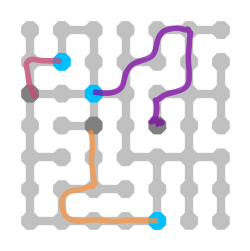

In [21]:
# example session
session = gs.get_maze_sessions(
    subject_IDs=["m6"], maze_names=["maze_2"], days_on_maze=[11], with_data=["navigation_df"], must_have_data=True
)

# plot example trajectories
reload(tp)
f, ax = plt.subplots(figsize=(3, 3), clear=True)
tp.plot_trial_trajectories(
    session, trials=[42, 43, 44], smooth_SD=5, cmap="plasma", goal_color="deepskyblue", linewidth=4, ax=ax
)
f.savefig(FIG_SAVE_PATH / "example_trajectories.pdf")

In [23]:
from GridMaze.maze import plotting as mp

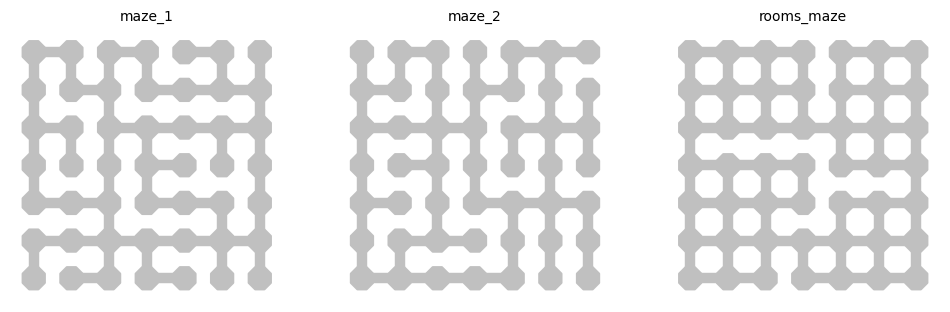

In [47]:
f, axes = plt.subplots(1, 3, figsize=(12, 4), clear=True)
mp.plot_maze_series(axes)
f.savefig(FIG_SAVE_PATH / "maze_series.pdf")

In [27]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import navigation_strategies as ns

reload(gs)

basic_behaviour_df = pm.get_basic_behaviour_df()
strategy_weights_df = ns.get_strategy_weights_across_subjects()

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     trial    
No. Observations:      210         Method:                 ML       
No. Groups:            6           Scale:                  108.5088 
Min. group size:       35          Log-Likelihood:         -798.0739
Max. group size:       35          Converged:              Yes      
Mean group size:       35.0                                         
--------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept              -25.439    4.690 -5.424 0.000 -34.631 -16.247
maze_order              34.539    1.851 18.658 0.000  30.911  38.167
day_on_maze              8.444    0.508 16.633 0.000   7.449   9.439
maze_order:day_on_maze  -2.072    0.254 -8.159 0.000  -2.570  -1.574
Group Var               41.214    2.492           

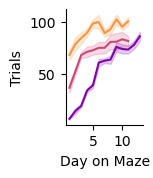

In [109]:
f, ax = plt.subplots(figsize=(1, 1.5))
pm._plot_trials(
    basic_behaviour_df,
    ax=ax,
    legend=False,
    cmap="plasma",
    print_stats=True,
)
f.savefig(FIG_SAVE_PATH / "trials.pdf")

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  n_excess_steps
No. Observations:    210      Method:              ML            
No. Groups:          6        Scale:               13.1579       
Min. group size:     35       Log-Likelihood:      -568.5647     
Max. group size:     35       Converged:           Yes           
Mean group size:     35.0                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              18.420    1.354 13.601 0.000 15.766 21.075
maze_order             -6.031    0.645 -9.355 0.000 -7.294 -4.767
day_on_maze            -1.565    0.177 -8.851 0.000 -1.911 -1.218
maze_order:day_on_maze  0.497    0.088  5.618 0.000  0.324  0.670
Group Var               0.000                                    



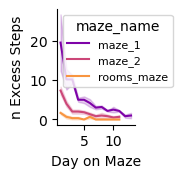

In [108]:
reload(pm)
f, ax = plt.subplots(figsize=(1, 1.5))
pm._plot_n_excess_steps(
    basic_behaviour_df,
    ax=ax,
    legend=True,
    cmap="plasma",
    print_stats=True,
)
f.savefig(FIG_SAVE_PATH / "excess_steps.pdf")

                               sum_sq    df          F        PR(>F)
C(maze_name)                 0.003090   2.0   0.316474  7.311174e-01
C(weight_type)               0.055457   1.0  11.361336  2.077751e-03
C(maze_name):C(weight_type)  0.708559   2.0  72.580810  3.200623e-12
Residual                     0.146435  30.0        NaN           NaN


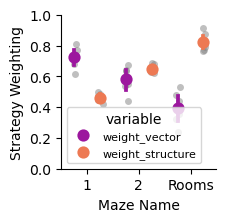

In [101]:
reload(ns)
f, ax = plt.subplots(figsize=(2, 2))
ns.plot_strategy_weights_cross_subject(
    strategy_weights_df,
    mazes=["maze_1", "maze_2", "rooms_maze"],
    ax=ax,
    colormap="plasma",
    print_stats=True,
)
f.savefig(FIG_SAVE_PATH / "strategy_weights.pdf")

In [87]:
strategy_weights_bootstrapped = ns.get_strategy_weights_across_sessions()

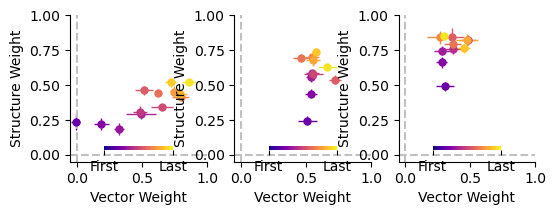

In [104]:
reload(ns)
f, axes = plt.subplots(1, 3, figsize=(6, 2))
ns.plot_nav_strategy_weights_over_sessions(strategy_weights_bootstrapped, cmap="plasma", fig=f, axes=axes)
f.savefig(FIG_SAVE_PATH / "strategy_weights_over_sessions.pdf")